In [1]:
import sccellfie
import scanpy as sc

/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warning

In [2]:
# Load the dataset
adata = sc.read(filename='./data/HECA-Subset.h5ad',
                backup_url='https://zenodo.org/records/15072628/files/HECA-Subset.h5ad')


/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████████████| 650M/650M [03:20<00:00, 3.40MB/s]


In [3]:
adata

AnnData object with n_obs × n_vars = 90001 × 17736
    obs: 'n_genes', 'sample', 'percent_mito', 'n_counts', 'Endometriosis_stage', 'Endometriosis', 'Hormonal treatment', 'Binary Stage', 'Stage', 'phase', 'dataset', 'Age', 'lineage', 'celltype', 'label_long'
    var: 'gene_ids', 'feature_types'
    uns: 'Binary Stage_colors', 'Biopsy_type_colors', 'Endometrial_pathology_colors', 'Endometriosis_stage_colors', 'GarciaAlonso_celltype_colors', 'Group_colors', 'Hormonal treatment_colors', 'Library_genotype_colors', 'Mareckova_celltype_colors', 'Mareckova_epi_celltype_colors', 'Mareckova_lineage_colors', 'Processing_colors', 'Symbol_colors', 'Tan_cellsubtypes_colors', 'Tan_celltype_colors', 'Treatment_colors', 'celltype_colors', 'dataset_colors', 'genotype_colors', 'hvg', 'label_long_colors', 'leiden', 'leiden_R_colors', 'leiden_colors', 'lineage_colors', 'neighbors', 'phase_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    obsp: 'connectivities', 'distances'

In [4]:

# Run one-command scCellFie pipeline
results = sccellfie.run_sccellfie_pipeline(adata,
                                           organism='human',
                                           sccellfie_data_folder=None,
                                           n_counts_col='n_counts',
                                           process_by_group=False,
                                           groupby=None,
                                           neighbors_key='neighbors',
                                           n_neighbors=10,
                                           batch_key='sample',
                                           threshold_key='sccellfie_threshold',
                                           smooth_cells=True,
                                           alpha=0.33,
                                           chunk_size=5000,
                                           disable_pbar=False,
                                           save_folder=None,
                                           save_filename=None
                                          )


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: human

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----


/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/sccellfie/preprocessing/adata_utils.py:151: UserWarning: Normalizing data.
  warnings.warn("Normalizing data.", UserWarning)



---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 22
Shape of new adata object: (90001, 839)
Number of GPRs: 748
Shape of tasks by genes: (215, 839)
Shape of reactions by genes: (748, 839)
Shape of tasks by reactions: (215, 748)

---- scCellFie Step: Smoothing gene expression ----


Smoothing Expression: 100%|█████████████████████| 19/19 [00:01<00:00, 13.30it/s]
/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/sccellfie/expression/smoothing.py:188: ImplicitModificationWarning: Setting element `.layers['smoothed_X']` of view, initializing view as actual.
  adata.layers[key_added] = smoothed_matrix



---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|███████████████| 90001/90001 [02:41<00:00, 558.79it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 0 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


In [7]:
results['adata'].metabolic_tasks.obs

,n_genes,sample,percent_mito,n_counts,Endometriosis_stage,Endometriosis,Hormonal treatment,Binary Stage,Stage,phase,dataset,Age,lineage,celltype,label_long
GSM6605437_CTATCCGCATATGAAG-Huang,1761,GSM6605437,0.185592,4463.0,0,Control,nan,Secretory,Secretory Mid,G1,Huang,29,Endothelial,Arterial,33 | Arterial
GSM6605440_GTCGAATCATGATCTG-Huang,3773,GSM6605440,0.078448,10644.0,0,Control,nan,Proliferative,Proliferative Early,G1,Huang,24,Endothelial,Arterial,33 | Arterial
GSM4577309_CTAACCCCAGGAAGTC-Wang,1836,GSM4577309,0.049842,3383.0,0,Control,nan,Secretory,Secretory Early-Mid,G1,Wang,18-34,Endothelial,Arterial,33 | Arterial
HCA_A_RepT_RNA13247830_GTAACTGAGCACAGGT-Mareckova,4091,HCA_A_RepT_RNA13247830,0.036753,12112.0,0,Control,nan,Proliferative,Proliferative,G1,Mareckova,37,Endothelial,Arterial,33 | Arterial
GSM6605437_ACTCCCACAAGGAGTC-Huang,7509,GSM6605437,0.054863,51555.0,0,Control,nan,Secretory,Secretory Mid,G1,Huang,29,Endothelial,Arterial,33 | Arterial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E07_EuE_GAGAGGTCAACTCCCT-Tan,3679,E07_EuE,0.069010,12794.0,4,Endometriosis,norethindrone/E2:1/10,Hormones,Hormones (Inactive),G1,Tan,34,Mesenchymal,sHormones,30 | sHormones
E03_EuE_GTGTGGCCATCCAATG-Tan,5029,E03_EuE,0.103877,23018.0,4,Endometriosis,norethindrone/E2:1/20,Hormones,Hormones (Inactive),G1,Tan,33,Mesenchymal,sHormones,30 | sHormones
E04_EuE_GTCACGGCATCGTCCT-Tan,3270,E04_EuE,0.080577,10401.0,4,Endometriosis,norethindrone/E2:1/20,Hormones,Hormones,G1,Tan,27,Mesenchymal,uSMCs,17 | uSMCs
GSM6605432_GTCACGGGTTCAAAGA-Huang,3336,GSM6605432,0.039425,13483.0,1,Endometriosis,nan,Proliferative,Proliferative Early,G1,Huang,30,Mesenchymal,uSMCs,17 | uSMCs


In [9]:
adata.obs

,n_genes,sample,percent_mito,n_counts,Endometriosis_stage,Endometriosis,Hormonal treatment,Binary Stage,Stage,phase,dataset,Age,lineage,celltype,label_long
GSM6605437_CTATCCGCATATGAAG-Huang,1761,GSM6605437,0.185592,4463.0,0,Control,nan,Secretory,Secretory Mid,G1,Huang,29,Endothelial,Arterial,33 | Arterial
GSM6605440_GTCGAATCATGATCTG-Huang,3773,GSM6605440,0.078448,10644.0,0,Control,nan,Proliferative,Proliferative Early,G1,Huang,24,Endothelial,Arterial,33 | Arterial
GSM4577309_CTAACCCCAGGAAGTC-Wang,1836,GSM4577309,0.049842,3383.0,0,Control,nan,Secretory,Secretory Early-Mid,G1,Wang,18-34,Endothelial,Arterial,33 | Arterial
HCA_A_RepT_RNA13247830_GTAACTGAGCACAGGT-Mareckova,4091,HCA_A_RepT_RNA13247830,0.036753,12112.0,0,Control,nan,Proliferative,Proliferative,G1,Mareckova,37,Endothelial,Arterial,33 | Arterial
GSM6605437_ACTCCCACAAGGAGTC-Huang,7509,GSM6605437,0.054863,51555.0,0,Control,nan,Secretory,Secretory Mid,G1,Huang,29,Endothelial,Arterial,33 | Arterial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E07_EuE_GAGAGGTCAACTCCCT-Tan,3679,E07_EuE,0.069010,12794.0,4,Endometriosis,norethindrone/E2:1/10,Hormones,Hormones (Inactive),G1,Tan,34,Mesenchymal,sHormones,30 | sHormones
E03_EuE_GTGTGGCCATCCAATG-Tan,5029,E03_EuE,0.103877,23018.0,4,Endometriosis,norethindrone/E2:1/20,Hormones,Hormones (Inactive),G1,Tan,33,Mesenchymal,sHormones,30 | sHormones
E04_EuE_GTCACGGCATCGTCCT-Tan,3270,E04_EuE,0.080577,10401.0,4,Endometriosis,norethindrone/E2:1/20,Hormones,Hormones,G1,Tan,27,Mesenchymal,uSMCs,17 | uSMCs
GSM6605432_GTCACGGGTTCAAAGA-Huang,3336,GSM6605432,0.039425,13483.0,1,Endometriosis,nan,Proliferative,Proliferative Early,G1,Huang,30,Mesenchymal,uSMCs,17 | uSMCs


In [13]:
# Summarize results in a cell-group level for the Metabolic Task Visualizer
report = sccellfie.reports.generate_report_from_adata(results['adata'].metabolic_tasks,
                                                      group_by='celltype',
                                                      feature_name='metabolic_task'
                                                      )

Processing tissues: 100%|█████████████████████████| 1/1 [00:01<00:00,  1.36s/it]


In [37]:
import scanpy as sc, anndata as ad
print("scanpy", sc.__version__)
print("anndata", ad.__version__)

scanpy 1.9.6
anndata 0.11.4


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_74633/1592069557.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


In [35]:
results['adata'].metabolic_tasks

AnnData object with n_obs × n_vars = 90001 × 215
    obs: 'n_genes', 'sample', 'percent_mito', 'n_counts', 'Endometriosis_stage', 'Endometriosis', 'Hormonal treatment', 'Binary Stage', 'Stage', 'phase', 'dataset', 'Age', 'lineage', 'celltype', 'label_long'
    uns: 'Binary Stage_colors', 'Biopsy_type_colors', 'Endometrial_pathology_colors', 'Endometriosis_stage_colors', 'GarciaAlonso_celltype_colors', 'Group_colors', 'Hormonal treatment_colors', 'Library_genotype_colors', 'Mareckova_celltype_colors', 'Mareckova_epi_celltype_colors', 'Mareckova_lineage_colors', 'Processing_colors', 'Symbol_colors', 'Tan_cellsubtypes_colors', 'Tan_celltype_colors', 'Treatment_colors', 'celltype_colors', 'dataset_colors', 'genotype_colors', 'hvg', 'label_long_colors', 'leiden', 'leiden_R_colors', 'leiden_colors', 'lineage_colors', 'neighbors', 'phase_colors', 'umap', 'normalization'
    obsm: 'X_scVI', 'X_umap'
    obsp: 'connectivities', 'distances'

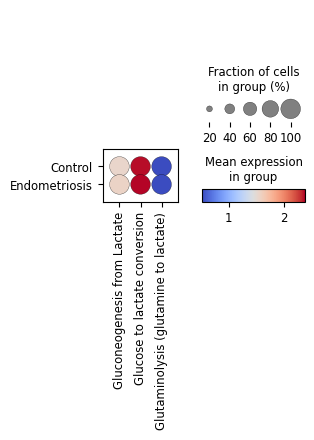

In [40]:
sc.pl.dotplot(
    results['adata'].metabolic_tasks,
    var_names=[i for i in results['adata'].metabolic_tasks.var.index if "lactate" in i.lower()],
    groupby="Endometriosis",
    color_map="coolwarm",
)

In [28]:
[i for i in results['adata'].metabolic_tasks.var.index if "lactate" in i.lower()]

['Gluconeogenesis from Lactate',
 'Glucose to lactate conversion',
 'Glutaminolysis (glutamine to lactate)']

/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  The key of the observations grouping to consider.
/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Use `raw` attribute of `adata` if present.
/Users/christoffer/miniconda3/envs/sccellfie/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:463: Perform

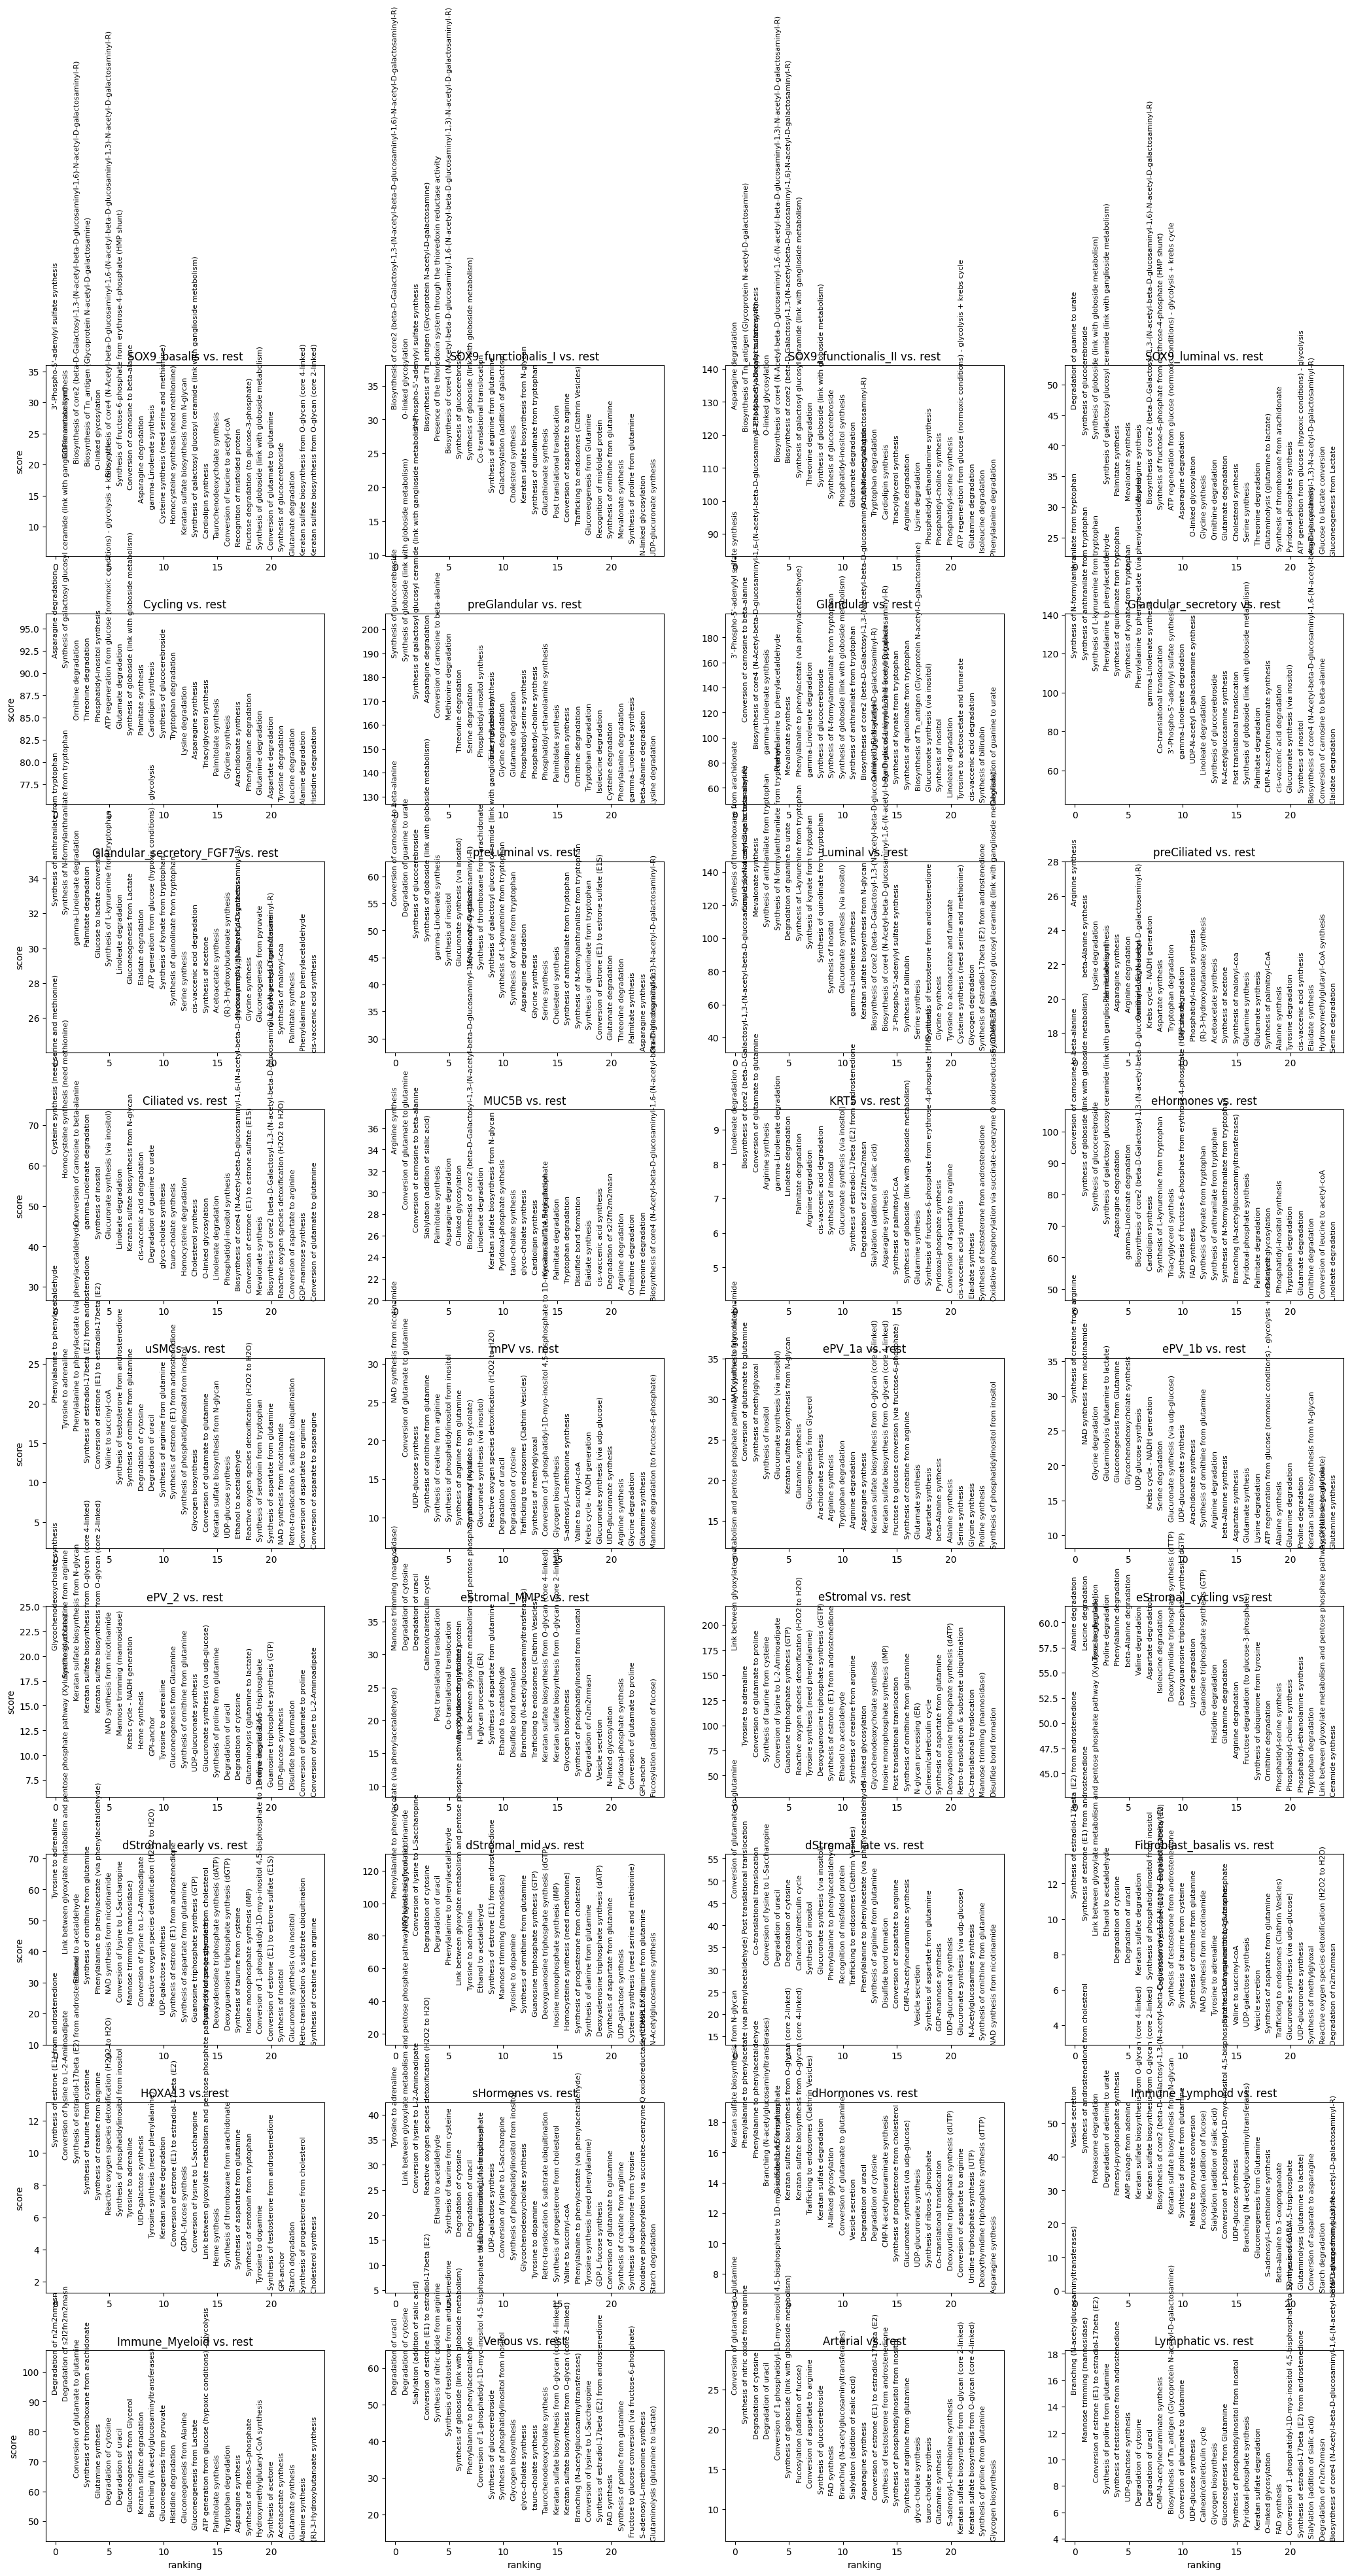

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,SOX9_basalis,3'-Phospho-5'-adenylyl sulfate synthesis,28.906342,3.227642,7.344833e-51,1.754599e-49
1,SOX9_basalis,GDP-mannose synthesis,21.109299,1.767317,6.817781e-39,1.221519e-37
2,SOX9_basalis,"Biosynthesis of core2 (beta-D-Galactosyl-1,3-(...",20.250921,1.750286,1.976997e-37,3.269650e-36
3,SOX9_basalis,Biosynthesis of Tn_antigen (Glycoprotein N-ace...,19.783903,2.450038,1.413361e-36,2.025818e-35
4,SOX9_basalis,O-linked glycosylation,19.233942,1.442062,1.313769e-35,1.661531e-34


In [41]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(results['adata'].metabolic_tasks, groupby="celltype", method="t-test")
sc.pl.rank_genes_groups(results['adata'].metabolic_tasks, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(results['adata'].metabolic_tasks, group=None)
markers.head()

In [43]:
import pandas as pd

In [44]:
marker_genes = pd.DataFrame({
    group: results['adata'].metabolic_tasks.uns['rank_genes_groups']['names'][group][:20]
    for group in results['adata'].metabolic_tasks.uns['rank_genes_groups']['names'].dtype.names
})


In [45]:
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

SOX9_basalis
3'-Phospho-5'-adenylyl sulfate synthesis GDP-mannose synthesis Biosynthesis of core2 (beta-D-Galactosyl-1,3-(N-acetyl-beta-D-glucosaminyl-1,6)-N-acetyl-D-galactosaminyl-R) Biosynthesis of Tn_antigen (Glycoprotein N-acetyl-D-galactosamine) O-linked glycosylation Biosynthesis of core4 (N-Acetyl-beta-D-glucosaminyl-1,6-(N-acetyl-beta-D-glucosaminyl-1,3)-N-acetyl-D-galactosaminyl-R) Synthesis of fructose-6-phosphate from erythrose-4-phosphate (HMP shunt) Conversion of carnosine to beta-alanine Asparagine degradation gamma-Linolenate synthesis Cysteine synthesis (need serine and methionine) Homocysteine synthesis (need methionine) Keratan sulfate biosynthesis from N-glycan Synthesis of galactosyl glucosyl ceramide (link with ganglioside metabolism) Cardiolipin synthesis Taurochenodeoxycholate synthesis Conversion of leucine to acetyl-coA Recognition of misfolded protein Fructose degradation (to glucose-3-phosphate) Synthesis of globoside (link with globoside metabolism)
 
SOX9_